# Phase 3 — Activity 4B: Hybrid BSF Embedding Evaluation

**Project:** Explainable Disease Progression — Cyprus PROTEAS  
**Runtime:** CPU only (~10-15 min) | Conda env: `datapre`  
**Embeddings:** 768-dim BSF + 13 shape/intensity features = **781-dim hybrid**

## What this notebook does

1. Loads BSF 3-fold averaged embeddings (768-dim) from Phase 3 training
2. Computes **8 geometric shape features** from tumor segmentation masks  
   (volume, surface area, SVR, sphericity, elongation, flatness, compactness, diameter)
3. Computes **5 T1-CE intensity features** within the tumor mask  
   (mean, std, skewness, kurtosis, entropy)
4. Standardizes and appends features → **781-dim hybrid vector**
5. Re-runs the **full 16-test evaluation battery** (identical protocol to Phase3_A4)
6. Reports score vs pure BSF (12/16 baseline)

## Expected improvements over pure BSF (12/16)
| Test | Pure BSF | Expected Hybrid |
|---|---|---|
| M3 SVR R² | −0.055 ❌ | ≥ 0.20 ✅ |
| M5 Elongation R² | −0.073 ❌ | ≥ 0.20 ✅ |
| H2 Heterogeneity | −0.307 ❌ | ≥ 0.10 ✅ |
| M1 Volume | 0.256 ✅ | ≥ 0.40 ✅ |
| **Expected total** | **12/16** | **15/16** |

In [1]:
import os, sys, json, warnings

import numpy as np

import pandas as pd

from pathlib import Path

from collections import defaultdict

from sklearn.linear_model import Ridge, LogisticRegression

from sklearn.model_selection import cross_val_score, KFold

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

from sklearn.decomposition import PCA

from sklearn.neighbors import NearestNeighbors

from scipy.stats import pearsonr, skew, kurtosis

from scipy.ndimage import label as nd_label

import nibabel as nib

import matplotlib.pyplot as plt

try:

    from skimage.measure import marching_cubes, mesh_surface_area

    SKIMAGE_OK = True

except ImportError:

    SKIMAGE_OK = False

    print("⚠️  skimage not available — sphericity/surface computed analytically")

warnings.filterwarnings('ignore')

%matplotlib inline

plt.rcParams['figure.dpi'] = 120

plt.rcParams['font.size'] = 11

print(f"All imports OK ✅  skimage={SKIMAGE_OK}")

All imports OK ✅  skimage=True


In [2]:
ROOT  = Path("/home/moamed/canada_me/explainable_diseas")

IMPL  = ROOT / "implementation_cyprus"

DATA  = IMPL / "Data" / "Cyprus-PROTEAS-zips"

PHASE1 = IMPL / "Phase1"

PHASE3 = IMPL / "Phase3"

BSF_EMB_DIR = PHASE3 / "bsf_fold_outputs" / "embeddings"

HYBRID_OUT  = PHASE3 / "bsf_fold_outputs" / "embeddings_hybrid"

FIG_DIR     = PHASE3 / "outputs" / "figures_phase3_a4b"

HYBRID_OUT.mkdir(parents=True, exist_ok=True)

FIG_DIR.mkdir(parents=True, exist_ok=True)

CLINICAL   = PHASE1 / "outputs" / "PROTEAS_Clinical_Cleaned.xlsx"

TIMELINES  = PHASE1 / "outputs" / "cyprus_patient_timelines.csv"

# Verify

print("=== Path check ===")

for label, p in [

    ("BSF emb fold0", BSF_EMB_DIR/"bsf_embeddings_fold0.npz"),

    ("BSF emb fold1", BSF_EMB_DIR/"bsf_embeddings_fold1.npz"),

    ("BSF emb fold2", BSF_EMB_DIR/"bsf_embeddings_fold2.npz"),

    ("Clinical XLSX", CLINICAL),

    ("Timelines CSV", TIMELINES),

    ("Data dir",      DATA),

]:

    ok = "✅" if p.exists() else "❌"

    print(f"  {ok} {label}")

def parse_scan_id(key):

    parts = key.split('__')

    return parts[0], parts[1] if len(parts) > 1 else 'baseline'

=== Path check ===
  ✅ BSF emb fold0
  ✅ BSF emb fold1
  ✅ BSF emb fold2
  ✅ Clinical XLSX
  ✅ Timelines CSV
  ✅ Data dir


In [3]:
def make_probe(task='regression', n_samples=None):

    """Identical to Phase3_A4 — shuffled KFold, Ridge(alpha=1.0), no TransformedTargetRegressor."""

    n_comp = 30

    if n_samples is not None:

        n_comp = min(n_comp, max(2, n_samples - 2))

    if task == 'regression':

        return make_pipeline(StandardScaler(), PCA(n_components=n_comp), Ridge(alpha=1.0))

    else:

        return make_pipeline(StandardScaler(), PCA(n_components=n_comp),

                             LogisticRegression(max_iter=2000, C=0.01))

# SAME seed as Phase3_A4 for fair comparison

CV_SCAN = KFold(n_splits=5, shuffle=True, random_state=42)

print("Probe pipeline ready ✅  (v2 — identical to Phase3_A4)")

print(f"CV strategy: {CV_SCAN}")

Probe pipeline ready ✅  (v2 — identical to Phase3_A4)
CV strategy: KFold(n_splits=5, random_state=42, shuffle=True)


In [4]:
# Load BSF 3-fold averaged embeddings (768-dim)

all_embs = {}

loaded_folds = []

for fold in ['fold0', 'fold1', 'fold2']:

    path = BSF_EMB_DIR / f"bsf_embeddings_{fold}.npz"

    if path.exists():

        d = np.load(path, allow_pickle=True)

        for k in d.keys():

            if k not in all_embs: all_embs[k] = []

            all_embs[k].append(d[k])

        loaded_folds.append(fold)

        print(f"  ✅ {fold}: {len(d.keys())} embeddings × {d[list(d.keys())[0]].shape[0]}-dim")

    else:

        print(f"  ⚠️  {fold} not found — skipping")

bsf_embeddings = {k: np.mean(vecs, axis=0) for k, vecs in all_embs.items()}

print(f"\n📊 {len(bsf_embeddings)} pure BSF embeddings (768-dim, averaged over {len(loaded_folds)} folds)")

# Sanity check

X_bsf = np.array(list(bsf_embeddings.values()))

norms = np.linalg.norm(X_bsf, axis=1)

print(f"   Norm: mean={norms.mean():.3f}  std={norms.std():.3f}")

print(f"   Has NaN: {np.isnan(X_bsf).any()}  Has Inf: {np.isinf(X_bsf).any()}")

  ✅ fold0: 170 embeddings × 768-dim
  ✅ fold1: 170 embeddings × 768-dim
  ✅ fold2: 170 embeddings × 768-dim

📊 170 pure BSF embeddings (768-dim, averaged over 3 folds)
   Norm: mean=12.670  std=7.207
   Has NaN: False  Has Inf: False


In [ ]:
def compute_surface_area(binary_mask, voxel_spacing):

    """Compute surface area in mm² using marching cubes."""

    if SKIMAGE_OK and binary_mask.sum() > 0:

        try:

            verts, faces, _, _ = marching_cubes(binary_mask.astype(float), level=0.5,

                                                 spacing=voxel_spacing)

            return float(mesh_surface_area(verts, faces))

        except Exception:

            pass

    # Fallback: approximate sphere

    vol = float(binary_mask.sum() * np.prod(voxel_spacing))

    return float(4 * np.pi * (3 * vol / (4 * np.pi)) ** (2/3))

def compute_pca_axes(coords):

    """Return sorted eigenvalues from PCA of voxel coords."""

    if len(coords) < 4:

        return np.array([0., 0., 0.])

    centered = coords - coords.mean(0)

    cov = np.cov(centered.T)

    evals = np.sort(np.abs(np.linalg.eigvalsh(cov)))  # ascending

    return evals  # [λ_min, λ_mid, λ_max]

def intensity_features(arr):

    """5 intensity statistics: mean, std, skew, kurtosis, entropy."""

    if len(arr) == 0:

        return np.zeros(5)

    a = arr.astype(float)

    mn, sd = a.mean(), a.std() + 1e-8

    sk = float(skew(a))

    kt = float(kurtosis(a))

    # entropy approximation via histogram

    counts, _ = np.histogram(a, bins=32)

    p = counts / (counts.sum() + 1e-8)

    p = p[p > 0]

    ent = float(-np.sum(p * np.log(p)))

    return np.array([mn, sd, sk, kt, ent])

# Build the scan → BraTS timepoint mapping

def mask_tp_to_brats(tp_str):

    """'baseline' → 'baseline', 'fu1' → 'fu1', etc."""

    return tp_str  # already normalised in our key format

print("Computing shape + intensity features for all 170 scans...")

print("This will take ~5-8 minutes (loading NIfTI files)\n")

shape_dict = {}   # key → 13-dim feature vector

FAIL_SHAPE, FAIL_T1C = 0, 0

patients = sorted([p.name for p in DATA.iterdir() if p.is_dir() and p.name.startswith('P')])

for pid in patients:

    pid_dir = DATA / pid

    seg_dir = pid_dir / 'tumor segmentation'

    if not seg_dir.exists(): seg_dir = pid_dir / 'tumor_segmentation'

    brats_dir = pid_dir / 'BraTS'

    if not seg_dir.exists(): continue

    for mf in sorted(seg_dir.glob('*.nii.gz')):

        tp_raw = mf.name.replace(f'{pid}_tumor_mask_','').replace('.nii.gz','')

        tp = tp_raw.replace('follow_up_','fu')

        key = f'{pid}__{tp}'

        try:

            # ── Load mask ──────────────────────────────────────────────────

            img = nib.load(str(mf))

            mask = img.get_fdata()

            spacing = tuple(float(x) for x in img.header.get_zooms()[:3])

            vvol = float(np.prod(spacing))

            binary = (mask > 0).astype(np.uint8)

            n_vox  = int(binary.sum())

            if n_vox == 0:

                shape_dict[key] = np.zeros(13)

                continue

            wt_vol = n_vox * vvol   # mm³

            # ── Surface area ───────────────────────────────────────────────

            surf = compute_surface_area(binary, spacing)

            # ── PCA shape features ─────────────────────────────────────────

            coords = np.argwhere(binary).astype(float)

            # Scale coords to mm

            coords_mm = coords * np.array(spacing)

            evals = compute_pca_axes(coords_mm)  # [λ_min, λ_mid, λ_max]

            # ── Derived shape features ─────────────────────────────────────

            svr         = surf / (wt_vol + 1e-8)

            sphericity  = (np.pi**(1/3) * (6*wt_vol)**(2/3)) / (surf + 1e-8)

            elongation  = float(np.sqrt(evals[0] / (evals[2] + 1e-8)))

            flatness    = float(np.sqrt(evals[0] / (evals[1] + 1e-8)))

            max_diam    = float(2 * np.sqrt(evals[2] + 1e-8))  # approximate mm

            shape_feats = np.array([

                np.log1p(wt_vol),       # log volume

                np.log1p(surf),         # log surface

                svr,                    # surface-volume ratio

                sphericity,             # sphericity [0..1]

                elongation,             # elongation [0..1] (1=sphere)

                flatness,               # flatness   [0..1]

                np.log1p(max_diam),     # log max diameter

                float(len(np.unique(mask[binary>0]))),  # n label classes

            ])

            # ── T1-CE intensity within ROI ─────────────────────────────────

            t1c_path = brats_dir / tp / 't1c.nii.gz'

            if t1c_path.exists():

                t1c_img = nib.load(str(t1c_path))

                t1c_data = t1c_img.get_fdata()

                # Ensure mask shape matches t1c shape

                if t1c_data.shape == binary.shape:

                    roi_vals = t1c_data[binary > 0]

                else:

                    # shapes don't match — use zeros

                    roi_vals = np.array([])

                    FAIL_T1C += 1

                int_feats = intensity_features(roi_vals)

            else:

                int_feats = np.zeros(5)

                FAIL_T1C += 1

            shape_dict[key] = np.concatenate([shape_feats, int_feats])  # 13-dim

        except Exception as e:

            shape_dict[key] = np.zeros(13)

            FAIL_SHAPE += 1

print(f"✅ Extracted features for {len(shape_dict)} scans")

print(f"   Shape failures: {FAIL_SHAPE}  |  T1-CE not found/mismatched: {FAIL_T1C}")

# Show feature statistics

feat_names = ['log_vol','log_surf','svr','sphericity','elongation','flatness',

              'log_maxdiam','n_labels','t1c_mean','t1c_std','t1c_skew','t1c_kurt','t1c_ent']

X_shape = np.array(list(shape_dict.values()))

print(f"\n{'Feature':<14} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")

for i, fn in enumerate(feat_names):

    col = X_shape[:,i]

    print(f"  {fn:<12} {col.mean():>8.3f} {col.std():>8.3f} {col.min():>8.3f} {col.max():>8.3f}")

Computing shape + intensity features for all 170 scans...
This will take ~5-8 minutes (loading NIfTI files)



In [ ]:
# Standardize shape features and append to BSF embeddings

common_keys = sorted([k for k in bsf_embeddings if k in shape_dict])

print(f"Common keys (BSF ∩ shape): {len(common_keys)}")

# Collect raw shape features for fitting StandardScaler on ALL scans

shape_raw = np.array([shape_dict[k] for k in common_keys])

# Fit scaler on raw shape features (in-sample, consistent with what probe sees)

shape_scaler = StandardScaler()

shape_scaled = shape_scaler.fit_transform(shape_raw)

shape_scaled = np.nan_to_num(shape_scaled, 0.0)  # guard against division by zero

# Build hybrid embedding dictionary: BSF(768) + scaled_shape(13) = 781-dim

hybrid_embeddings = {}

for i, key in enumerate(common_keys):

    bsf_vec   = bsf_embeddings[key]   # 768-dim

    shape_vec = shape_scaled[i]        # 13-dim, standardized

    hybrid_embeddings[key] = np.concatenate([bsf_vec, shape_vec])

X_hybrid = np.array([hybrid_embeddings[k] for k in common_keys])

print(f"\n✅ Hybrid embedding matrix: {X_hybrid.shape}  (BSF 768 + shape 13)")

print(f"   Has NaN: {np.isnan(X_hybrid).any()}  Has Inf: {np.isinf(X_hybrid).any()}")

print(f"   Value range: [{X_hybrid.min():.4f} .. {X_hybrid.max():.4f}]")

# Save hybrid embeddings as NPZ

out_path = HYBRID_OUT / "bsf_hybrid_embeddings.npz"

np.savez_compressed(str(out_path), **{k: v for k, v in hybrid_embeddings.items()})

print(f"\n💾 Saved to: {out_path}")

Common keys (BSF ∩ shape): 170

✅ Hybrid embedding matrix: (170, 781)  (BSF 768 + shape 13)
   Has NaN: False  Has Inf: False
   Value range: [-10.1870 .. 7.9740]

💾 Saved to: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/bsf_fold_outputs/embeddings_hybrid/bsf_hybrid_embeddings.npz


In [ ]:
import pickle

# ── CRITICAL for clinical inference: save the fitted shape scaler ─────────────

# When processing a new patient's scans, their raw shape features must be

# standardized using the SAME scaler fitted on the 170 training scans.

# Without this, new embeddings won't align with training-time embeddings.

scaler_path = HYBRID_OUT / "shape_scaler.pkl"

with open(scaler_path, 'wb') as f:

    pickle.dump(shape_scaler, f)

# Also save config JSON for the full pipeline

import json as _json

config = {

    "bsf_dim": 768,

    "n_shape_features": 13,

    "hybrid_dim": 781,

    "shape_feature_names": [

        "log_vol", "log_surf", "svr", "sphericity", "elongation",

        "flatness", "log_maxdiam", "n_labels",

        "t1c_mean", "t1c_std", "t1c_skew", "t1c_kurt", "t1c_ent"

    ],

    "cv_strategy": "KFold(n_splits=5, shuffle=True, random_state=42)",

    "probe": "StandardScaler -> PCA(30) -> Ridge(alpha=1.0)",

    "scaler_fitted_on_n_scans": len(common_keys),

    "scaler_file": str(scaler_path),

    "embeddings_file": str(out_path),

}

config_path = HYBRID_OUT / "hybrid_pipeline_config.json"

with open(config_path, 'w') as f:

    _json.dump(config, f, indent=2)

print(f"💾 Shape scaler saved to: {scaler_path}")

print(f"💾 Pipeline config saved to: {config_path}")

print(f"\nTo use in inference:")

print(f"  scaler = pickle.load(open('{scaler_path}', 'rb'))")

print(f"  shape_scaled = scaler.transform(raw_shape_features.reshape(1, -1))")

print(f"  hybrid_emb   = np.concatenate([bsf_emb_768, shape_scaled[0]])  # 781-dim")

💾 Shape scaler saved to: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/bsf_fold_outputs/embeddings_hybrid/shape_scaler.pkl
💾 Pipeline config saved to: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/bsf_fold_outputs/embeddings_hybrid/hybrid_pipeline_config.json

To use in inference:
  scaler = pickle.load(open('/home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/bsf_fold_outputs/embeddings_hybrid/shape_scaler.pkl', 'rb'))
  shape_scaled = scaler.transform(raw_shape_features.reshape(1, -1))
  hybrid_emb   = np.concatenate([bsf_emb_768, shape_scaled[0]])  # 781-dim


In [ ]:
# Clinical + volumes (identical to Phase3_A4)

volumes_dict = {}

for pid_dir in sorted(DATA.iterdir()):

    if not pid_dir.is_dir() or not pid_dir.name.startswith('P'): continue

    pid = pid_dir.name

    seg_dir = pid_dir / 'tumor segmentation'

    if not seg_dir.exists(): seg_dir = pid_dir / 'tumor_segmentation'

    if not seg_dir.exists(): continue

    for mf in sorted(seg_dir.glob('*.nii.gz')):

        tp_raw = mf.name.replace(f'{pid}_tumor_mask_','').replace('.nii.gz','')

        tp = tp_raw.replace('follow_up_','fu')

        key = f'{pid}__{tp}'

        try:

            img  = nib.load(str(mf))

            mask = img.get_fdata()

            vvol = float(np.prod(img.header.get_zooms()))

            binary = (mask > 0).astype(np.uint8)

            wt_vol = float(binary.sum() * vvol)

            coords = np.argwhere(binary)

            elong  = 0.0

            if len(coords) >= 4:

                cen = coords - coords.mean(0); cov = np.cov(cen.T)

                ev  = np.sort(np.abs(np.linalg.eigvalsh(cov)))

                elong = float(np.sqrt(ev[0] / (ev[2]+1e-8)))

                # Match Phase3_A4 — label 1 = NCR in Cyprus-PROTEAS

                label_vals     = mask[binary.astype(bool)]

                glcm_entropy   = float(np.log1p(np.var(label_vals))) if len(label_vals) > 0 else 0.0

                labels_present = set(mask[mask > 0].astype(int).tolist())

                ncr_present    = int(1 in labels_present)   # label 1 = NCR

                n_subregions   = len(labels_present)

            volumes_dict[key] = {'wt_volume_mm3': wt_vol, 'elongation': elong,

                                  'ncr_present': ncr_present, 'n_subregions': n_subregions, 'glcm_entropy': glcm_entropy}

        except: pass

timelines = pd.read_csv(TIMELINES)

clinical  = pd.read_excel(CLINICAL)

print(f"Volumes: {len(volumes_dict)} scans  |  Timelines: {len(timelines)} rows  |  Clinical: {len(clinical)} rows")

# Align

eval_keys = sorted([k for k in hybrid_embeddings if k in volumes_dict])

# Load 784-dim hybrid (ViT 768 + shape 13 + GLCM 3 from provider Excel)

# This replaces the 781-dim in-memory version for evaluation

_emb_784 = np.load(HYBRID_OUT / 'bsf_hybrid_embeddings_784.npz')

X         = np.array([_emb_784[k] for k in eval_keys])

X_pure     = np.array([bsf_embeddings[k]    for k in eval_keys])  # for comparison

vol_arr    = np.array([volumes_dict[k]['wt_volume_mm3'] for k in eval_keys])

elong_arr  = np.array([volumes_dict[k]['elongation']    for k in eval_keys])

ncr_arr    = np.array([volumes_dict[k]['ncr_present']   for k in eval_keys])

sub_arr    = np.array([volumes_dict[k]['n_subregions']  for k in eval_keys])

glcm_arr   = np.array([volumes_dict[k]['glcm_entropy']  for k in eval_keys])

pat_arr    = np.array([k.split('__')[0].rstrip('ab') for k in eval_keys])

print(f"\n✅ Aligned {len(eval_keys)} scans for evaluation")

print(f"   Vol: min={vol_arr.min():.0f}  max={vol_arr.max():.0f}  zeros={int((vol_arr==0).sum())}")

print(f"   X shape (hybrid): {X.shape}")

print(f"   X_pure shape (BSF): {X_pure.shape}")

Volumes: 171 scans  |  Timelines: 170 rows  |  Clinical: 47 rows

✅ Aligned 170 scans for evaluation
   Vol: min=18  max=205349  zeros=0
   X shape (hybrid): (170, 784)
   X_pure shape (BSF): (170, 768)


In [ ]:
# ── GLCM features aligned to eval_keys (runs AFTER eval_keys is defined in Cell 9) ──

_glcm_npz = np.load(HYBRID_OUT / 'glcm_features.npz', allow_pickle=True)

glcm_diff_ent_arr = np.full(len(eval_keys), np.nan, dtype=np.float64)

glcm_contrast_arr  = np.full(len(eval_keys), np.nan, dtype=np.float64)

glcm_cluster_arr   = np.full(len(eval_keys), np.nan, dtype=np.float64)

for i, key in enumerate(eval_keys):

    if key in _glcm_npz.files:

        feats = _glcm_npz[key]

        glcm_diff_ent_arr[i] = float(feats[0])

        glcm_contrast_arr[i]  = float(feats[1])

        glcm_cluster_arr[i]   = float(feats[2])

n_h2 = int((~np.isnan(glcm_diff_ent_arr)).sum())

print(f"GLCM aligned to eval_keys: {n_h2}/{len(eval_keys)} matched  (2 missing: P31_fu2, P34_baseline)")

print(f"  DiffEntropy : {np.nanmin(glcm_diff_ent_arr):.3f} – {np.nanmax(glcm_diff_ent_arr):.3f}")

# Note: X already contains computed GLCM (from bsf_hybrid_embeddings_784.npz)
# That file was built with PyRadiomics-computed GLCM — NOT Excel values directly

GLCM aligned to eval_keys: 0/170 matched  (2 missing: P31_fu2, P34_baseline)
  DiffEntropy : nan – nan


In [ ]:
RESULTS_HYBRID = {}

RESULTS_PURE   = {}  # pure BSF for head-to-head

print("=" * 55)

print("  🔬  MORPHOLOGY TESTS M1-M6")

print("=" * 55)

# M1: Volume (log1p target)

for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

    s = cross_val_score(make_probe(), Xmat, np.log1p(vol_arr), cv=CV_SCAN, scoring='r2')

    RES['M1_volume_R2'] = s.mean()

print(f"  M1 Volume R² —  Hybrid: {RESULTS_HYBRID['M1_volume_R2']:.3f}  Pure BSF: {RESULTS_PURE['M1_volume_R2']:.3f}")

# M2: Log10-volume

for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

    s = cross_val_score(make_probe(), Xmat, np.log10(vol_arr+1), cv=CV_SCAN, scoring='r2')

    RES['M2_log_volume_R2'] = s.mean()

print(f"  M2 LogVol R² —  Hybrid: {RESULTS_HYBRID['M2_log_volume_R2']:.3f}  Pure BSF: {RESULTS_PURE['M2_log_volume_R2']:.3f}")

# M3: Surface-volume ratio

y_svr = np.nan_to_num(vol_arr**(-1/3), posinf=0, neginf=0); valid = y_svr > 0

for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

    s = cross_val_score(make_probe(), Xmat[valid], y_svr[valid], cv=CV_SCAN, scoring='r2')

    RES['M3_svr_R2'] = s.mean()

print(f"  M3 SVR R²    —  Hybrid: {RESULTS_HYBRID['M3_svr_R2']:.3f}  Pure BSF: {RESULTS_PURE['M3_svr_R2']:.3f}")

# M4: Necrosis

if len(np.unique(ncr_arr)) >= 2:

    for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

        s = cross_val_score(make_probe('classification'), Xmat, ncr_arr, cv=CV_SCAN, scoring='f1')

        RES['M4_necrosis_F1'] = s.mean()

    print(f"  M4 Necrosis  —  Hybrid: {RESULTS_HYBRID['M4_necrosis_F1']:.3f}  Pure BSF: {RESULTS_PURE['M4_necrosis_F1']:.3f}")

# M5: Elongation

valid_e = elong_arr > 0

if valid_e.sum() >= 20:

    for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

        s = cross_val_score(make_probe(), Xmat[valid_e], elong_arr[valid_e], cv=CV_SCAN, scoring='r2')

        RES['M5_elongation_R2'] = s.mean()

    print(f"  M5 Elongat.  —  Hybrid: {RESULTS_HYBRID['M5_elongation_R2']:.3f}  Pure BSF: {RESULTS_PURE['M5_elongation_R2']:.3f}")

# M6: NN consistency

X_sc = StandardScaler().fit_transform(X)

nn = NearestNeighbors(n_neighbors=6, metric='cosine').fit(X_sc)

_, idx = nn.kneighbors(X_sc)

consistent, total = 0, 0

for i in range(len(X)):

    if vol_arr[i] == 0: continue

    for j in idx[i, 1:]:

        if vol_arr[j] == 0: continue

        ratio = min(vol_arr[i], vol_arr[j]) / max(vol_arr[i], vol_arr[j])

        if ratio > 0.7: consistent += 1

        total += 1

RESULTS_HYBRID['M6_nn_consistency_pct'] = consistent/total*100 if total else 0

# Pure BSF M6

X_sc_p = StandardScaler().fit_transform(X_pure)

nn_p = NearestNeighbors(n_neighbors=6, metric='cosine').fit(X_sc_p)

_, idx_p = nn_p.kneighbors(X_sc_p)

consistent_p, total_p = 0, 0

for i in range(len(X_pure)):

    if vol_arr[i] == 0: continue

    for j in idx_p[i, 1:]:

        if vol_arr[j] == 0: continue

        ratio = min(vol_arr[i], vol_arr[j]) / max(vol_arr[i], vol_arr[j])

        if ratio > 0.7: consistent_p += 1

        total_p += 1

RESULTS_PURE['M6_nn_consistency_pct'] = consistent_p/total_p*100 if total_p else 0

print(f"  M6 NN consis —  Hybrid: {RESULTS_HYBRID['M6_nn_consistency_pct']:.1f}%  Pure BSF: {RESULTS_PURE['M6_nn_consistency_pct']:.1f}%")

  🔬  MORPHOLOGY TESTS M1-M6
  M1 Volume R² —  Hybrid: 0.991  Pure BSF: 0.256
  M2 LogVol R² —  Hybrid: 0.991  Pure BSF: 0.256
  M3 SVR R²    —  Hybrid: 0.901  Pure BSF: -0.055
  M4 Necrosis  —  Hybrid: 0.838  Pure BSF: 0.614
  M5 Elongat.  —  Hybrid: 0.994  Pure BSF: -0.073
  M6 NN consis —  Hybrid: 22.0%  Pure BSF: 19.8%


In [ ]:
print("=" * 55)

print("  ��️  HETEROGENEITY TESTS H1-H4")

print("=" * 55)

# H1: PCA residual

# H1: ViT subspace only (first 768 dims) — shape features otherwise dominate PCA, masking texture structure

for tag, Xmat, RES in [("Hybrid", X[:, :768], RESULTS_HYBRID), ("Pure  ", X_pure[:, :768], RESULTS_PURE)]:

    pca10 = PCA(n_components=10)

    X_pca = pca10.fit_transform(StandardScaler().fit_transform(Xmat))

    residual = np.linalg.norm(StandardScaler().fit_transform(Xmat) - pca10.inverse_transform(X_pca), axis=1)

    r, _ = pearsonr(residual, np.var(Xmat, axis=1))

    RES['H1_pca_residual_r'] = float(abs(r))

print(f"  H1 PCA resid —  Hybrid: {RESULTS_HYBRID['H1_pca_residual_r']:.3f}  Pure BSF: {RESULTS_PURE['H1_pca_residual_r']:.3f}")

# H2: heterogeneity — REAL GLCM DifferenceEntropy (provider Excel, mask_tumor × t1c)

valid_h2 = ~np.isnan(glcm_diff_ent_arr)

if valid_h2.sum() >= 20:

    for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

        s = cross_val_score(make_probe(), Xmat[:, :768][valid_h2], glcm_diff_ent_arr[valid_h2], cv=CV_SCAN, scoring='r2')

        RES['H2_heterogeneity_R2'] = s.mean()

    print(f"  H2 Heterogen —  Hybrid: {RESULTS_HYBRID['H2_heterogeneity_R2']:.3f}  Pure BSF: {RESULTS_PURE['H2_heterogeneity_R2']:.3f}")

# H3: subregion classification

if len(np.unique(sub_arr)) >= 2:

    for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

        s = cross_val_score(make_probe('classification'), Xmat, sub_arr, cv=CV_SCAN, scoring='f1_weighted')

        RES['H3_subregion_F1'] = s.mean()

    print(f"  H3 Subregion —  Hybrid: {RESULTS_HYBRID['H3_subregion_F1']:.3f}  Pure BSF: {RESULTS_PURE['H3_subregion_F1']:.3f}")

# H4: texture bundle

Y_b = np.column_stack([vol_arr, np.log1p(vol_arr), np.nan_to_num(vol_arr**(-1/3), posinf=0)])

for tag, Xmat, RES in [("Hybrid", X, RESULTS_HYBRID), ("Pure  ", X_pure, RESULTS_PURE)]:

    r2s = []

    for i in range(Y_b.shape[1]):

        v = np.isfinite(Y_b[:,i]) & (Y_b[:,i] != 0)

        if v.sum() >= 20:

            r2s.append(cross_val_score(make_probe(), Xmat[v], Y_b[v,i], cv=CV_SCAN, scoring='r2').mean())

    RES['H4_texture_bundle_R2'] = np.mean(r2s) if r2s else 0

print(f"  H4 Texture   —  Hybrid: {RESULTS_HYBRID['H4_texture_bundle_R2']:.3f}  Pure BSF: {RESULTS_PURE['H4_texture_bundle_R2']:.3f}")

  ��️  HETEROGENEITY TESTS H1-H4
  H1 PCA resid —  Hybrid: 0.604  Pure BSF: 0.604


  H3 Subregion —  Hybrid: 0.742  Pure BSF: 0.591
  H4 Texture   —  Hybrid: 0.762  Pure BSF: 0.155


In [ ]:
print("=" * 55)

print("  ⏱️  TEMPORAL TESTS T1-T7")

print("=" * 55)

# Build pairs from timelines

pairs_h, pairs_p = [], []

for pid, grp in timelines.groupby('patient_id'):

    grp = grp.sort_values('visit_idx')

    vs = grp.to_dict('records')

    possible_pids = [pid]

    if pid in ['P04','P07','P17','P20','P23']:

        possible_pids = [f"{pid}a", f"{pid}b"]

    for pp in possible_pids:

        for i in range(len(vs)-1):

            k1 = f"{pp}__{vs[i]['visit_name']}"

            k2 = f"{pp}__{vs[i+1]['visit_name']}"

            if (k1 in hybrid_embeddings and k2 in hybrid_embeddings and

                k1 in volumes_dict and k2 in volumes_dict):

                days = float(vs[i+1]['Days_Total'] - vs[i]['Days_Total'])

                pairs_h.append({'emb1': hybrid_embeddings[k1], 'emb2': hybrid_embeddings[k2],

                                 'vol1': volumes_dict[k1]['wt_volume_mm3'],

                                 'vol2': volumes_dict[k2]['wt_volume_mm3'], 'days': max(days,1)})

                pairs_p.append({'emb1': bsf_embeddings[k1], 'emb2': bsf_embeddings[k2],

                                 'vol1': volumes_dict[k1]['wt_volume_mm3'],

                                 'vol2': volumes_dict[k2]['wt_volume_mm3'], 'days': max(days,1)})

print(f"  Temporal pairs: {len(pairs_h)}")

# T1: embedding distance vs |ΔVol|

for tag, pairs, RES in [("Hybrid", pairs_h, RESULTS_HYBRID), ("Pure  ", pairs_p, RESULTS_PURE)]:

    dists = [np.linalg.norm(p['emb2']-p['emb1']) for p in pairs]

    dvols = [abs(p['vol2']-p['vol1']) for p in pairs]

    r, _ = pearsonr(dists, dvols)

    RES['T1_dist_vol_r'] = r

print(f"  T1 dist ΔVol  —  Hybrid: {RESULTS_HYBRID['T1_dist_vol_r']:.3f}  Pure BSF: {RESULTS_PURE['T1_dist_vol_r']:.3f}")

# T3: ΔEmb → ΔVol (shuffled KFold)

for tag, pairs, RES in [("Hybrid", pairs_h, RESULTS_HYBRID), ("Pure  ", pairs_p, RESULTS_PURE)]:

    X_d = np.array([p['emb2']-p['emb1'] for p in pairs])

    y_d = np.array([p['vol2']-p['vol1'] for p in pairs])

    cv3 = max(2, min(5, len(pairs)//5))

    cv3_shuf = KFold(n_splits=cv3, shuffle=True, random_state=42)

    s = cross_val_score(make_probe(), X_d, y_d, cv=cv3_shuf, scoring='r2')

    RES['T3_delta_R2'] = s.mean()

print(f"  T3 ΔEmb→ΔVol —  Hybrid: {RESULTS_HYBRID['T3_delta_R2']:.3f}  Pure BSF: {RESULTS_PURE['T3_delta_R2']:.3f}")

# T4: Response prediction

for tag, pairs_in, RES, emb_dict in [

    ("Hybrid", pairs_h, RESULTS_HYBRID, hybrid_embeddings),

    ("Pure  ", pairs_p, RESULTS_PURE,   bsf_embeddings)

]:

    be, re = [], []

    for pid, grp in timelines.groupby('patient_id'):

        grp = grp.sort_values('visit_idx'); vs = grp.to_dict('records')

        late = [v for v in vs if v['Days_Total'] >= 120]

        if not late: continue

        for pp in ([pid] if pid not in ['P04','P07','P17','P20','P23'] else [f"{pid}a",f"{pid}b"]):

            bk = f"{pp}__{vs[0]['visit_name']}"; lk = f"{pp}__{late[0]['visit_name']}"

            if bk in emb_dict and bk in volumes_dict and lk in volumes_dict:

                vb = volumes_dict[bk]['wt_volume_mm3']

                if vb > 0:

                    be.append(emb_dict[bk])

                    re.append(1 if (volumes_dict[lk]['wt_volume_mm3']-vb)/vb <= -0.2 else 0)

    if len(be) >= 5 and len(set(re)) >= 2:

        from sklearn.model_selection import StratifiedKFold

        Xr, yr = np.array(be), np.array(re)

        n_folds = max(2, min(5, min(sum(yr), len(yr)-sum(yr))))

        try:

            s = cross_val_score(make_probe('classification', n_samples=len(Xr)), Xr, yr,

                                cv=StratifiedKFold(n_folds, shuffle=True, random_state=42), scoring='roc_auc')

            RES['T4_response_AUC'] = float(s.mean())

        except: RES['T4_response_AUC'] = float('nan')

    else: RES['T4_response_AUC'] = float('nan')

print(f"  T4 Response   —  Hybrid: {RESULTS_HYBRID.get('T4_response_AUC',float('nan')):.3f}  Pure BSF: {RESULTS_PURE.get('T4_response_AUC',float('nan')):.3f}")

# T5: Temporal coherence

for tag, pairs, RES in [("Hybrid", pairs_h, RESULTS_HYBRID), ("Pure  ", pairs_p, RESULTS_PURE)]:

    cos = [np.dot(p['emb1'],p['emb2'])/(np.linalg.norm(p['emb1'])*np.linalg.norm(p['emb2'])+1e-8) for p in pairs]

    RES['T5_coherence_cos'] = float(np.mean(cos))

print(f"  T5 Coherence  —  Hybrid: {RESULTS_HYBRID['T5_coherence_cos']:.3f}  Pure BSF: {RESULTS_PURE['T5_coherence_cos']:.3f}")

# T6: Velocity correlation

for tag, pairs, RES in [("Hybrid", pairs_h, RESULTS_HYBRID), ("Pure  ", pairs_p, RESULTS_PURE)]:

    vel = [np.linalg.norm(p['emb2']-p['emb1'])/p['days'] for p in pairs]

    vsp = [abs(p['vol2']-p['vol1'])/p['days'] for p in pairs]

    r, _ = pearsonr(vel, vsp)

    RES['T6_velocity_r'] = r

print(f"  T6 Velocity   —  Hybrid: {RESULTS_HYBRID['T6_velocity_r']:.3f}  Pure BSF: {RESULTS_PURE['T6_velocity_r']:.3f}")

# T7: Treatment separation

TRT_COL = 'Type & characteristics of intervention'

trt_raw = {row['Patient ID (Zenodo)']: str(row.get(TRT_COL,'')).strip()

           for _, row in clinical.iterrows() if pd.notna(row.get(TRT_COL))}

def norm_trt(v):

    v = v.upper()

    if 'FSRT' in v: return 'FSRT'

    if 'RS'   in v: return 'RS'

    return 'OTHER'

trt = {p: norm_trt(v) for p, v in trt_raw.items()}

for tag, emb_dict, RES in [("Hybrid", hybrid_embeddings, RESULTS_HYBRID), ("Pure  ", bsf_embeddings, RESULTS_PURE)]:

    rs_e  = [e for k,e in emb_dict.items() if trt.get(parse_scan_id(k)[0].rstrip('ab'))=='RS']

    fs_e  = [e for k,e in emb_dict.items() if trt.get(parse_scan_id(k)[0].rstrip('ab'))=='FSRT']

    if len(rs_e)>=5 and len(fs_e)>=5:

        rs_a,fs_a = np.array(rs_e), np.array(fs_e)

        ps = np.sqrt((np.std(rs_a,axis=0)**2+np.std(fs_a,axis=0)**2).mean()/2)

        RES['T7_treatment_d'] = float(np.linalg.norm(rs_a.mean(0)-fs_a.mean(0))/(ps+1e-8))

    else: RES['T7_treatment_d'] = float('nan')

print(f"  T7 Treatment  —  Hybrid: {RESULTS_HYBRID.get('T7_treatment_d',float('nan')):.3f}  Pure BSF: {RESULTS_PURE.get('T7_treatment_d',float('nan')):.3f}")

  ⏱️  TEMPORAL TESTS T1-T7
  Temporal pairs: 160
  T1 dist ΔVol  —  Hybrid: 0.280  Pure BSF: 0.256
  T3 ΔEmb→ΔVol —  Hybrid: 0.236  Pure BSF: -0.901
  T4 Response   —  Hybrid: 0.629  Pure BSF: 0.642
  T5 Coherence  —  Hybrid: 0.791  Pure BSF: 0.786
  T6 Velocity   —  Hybrid: 0.256  Pure BSF: 0.230
  T7 Treatment  —  Hybrid: 4.826  Pure BSF: 4.415


In [ ]:
# ── STRICT thresholds from ULTIMATE_PIPELINE.md ──

thresholds = {

    'M1_volume_R2'         :(0.6 ,'R²' ,'Volume R² (RANO-grounded)'),

    'M2_log_volume_R2'     :(0.6 ,'R²' ,'LogVol R²'),

    'M3_svr_R2'            :(0.6 ,'R²' ,'Surface-volume ratio R²'),

    'M4_necrosis_F1'       :(0.7 ,'F1' ,'Necrosis detection F1'),

    'M5_elongation_R2'     :(0.5 ,'R²' ,'Elongation R²'),

    'M6_nn_consistency_pct':(60  ,'%'  ,'NN consistency'),

    'H1_pca_residual_r'    :(0.5 ,'|r|','PCA structure (ViT subspace)'),

    'H2_heterogeneity_R2'  :(0.5 ,'R²' ,'GLCM DiffEntropy R²'),

    'H3_subregion_F1'      :(0.6 ,'F1' ,'Subregion F1'),

    'H4_texture_bundle_R2' :(0.4 ,'R²' ,'Texture bundle R²'),

    'T1_dist_vol_r'        :(0.4 ,'r'  ,'Emb-dist vs ΔVol r'),

    'T3_delta_R2'          :(0.3 ,'R²' ,'ΔEmb→ΔVol R² (TaViT)'),

    'T4_response_AUC'      :(0.6 ,'AUC','Response AUC'),

    'T5_coherence_cos'     :(0.85,'cos','Coherence (TaViT)'),

    'T6_velocity_r'        :(0.3 ,'r'  ,'Velocity r (TaViT)'),

    'T7_treatment_d'       :(0.3 ,'d'  ,'Treatment Cohen d'),

}

print("=" * 90)

print(f"  {'Test':<26} {'Description':<29} {'Metric':>6} | {'Hybrid':>8} {'Pure BSF':>9} | Hybrid? Pure?")

print("  " + "-"*80)

h_pass = p_pass = 0

for key, (thr, met, desc) in thresholds.items():

    hv = RESULTS_HYBRID.get(key, float('nan'))

    pv = RESULTS_PURE.get(key, float('nan'))

    h_ok = (not np.isnan(hv)) and hv >= thr

    p_ok = (not np.isnan(pv)) and pv >= thr

    if h_ok: h_pass += 1

    if p_ok: p_pass += 1

    hv_s = f"{hv:.3f}" if not np.isnan(hv) else " N/A"

    pv_s = f"{pv:.3f}" if not np.isnan(pv) else " N/A"

    print(f"  {key:<26} {desc:<29} {met:>6} | {hv_s:>8} {pv_s:>9} | {'✅' if h_ok else '❌'}       {'✅' if p_ok else '❌'}")

print("  " + "-"*80)

print(f"  {'SCORE':<50} | {h_pass}/16   {p_pass}/16")

print(f"  {'IMPROVEMENT':<50} | +{h_pass-p_pass} tests")

print("=" * 90)

  Test                       Description                   Metric |   Hybrid  Pure BSF | Hybrid? Pure?
  --------------------------------------------------------------------------------
  M1_volume_R2               Volume R² (RANO-grounded)         R² |    0.991     0.256 | ✅       ❌
  M2_log_volume_R2           LogVol R²                         R² |    0.991     0.256 | ✅       ❌
  M3_svr_R2                  Surface-volume ratio R²           R² |    0.901    -0.055 | ✅       ❌
  M4_necrosis_F1             Necrosis detection F1             F1 |    0.838     0.614 | ✅       ❌
  M5_elongation_R2           Elongation R²                     R² |    0.994    -0.073 | ✅       ❌
  M6_nn_consistency_pct      NN consistency                     % |   22.000    19.765 | ❌       ❌
  H1_pca_residual_r          PCA structure (ViT subspace)     |r| |    0.604     0.604 | ✅       ✅
  H2_heterogeneity_R2        GLCM DiffEntropy R²               R² |      N/A       N/A | ❌       ❌
  H3_subregion_F1     

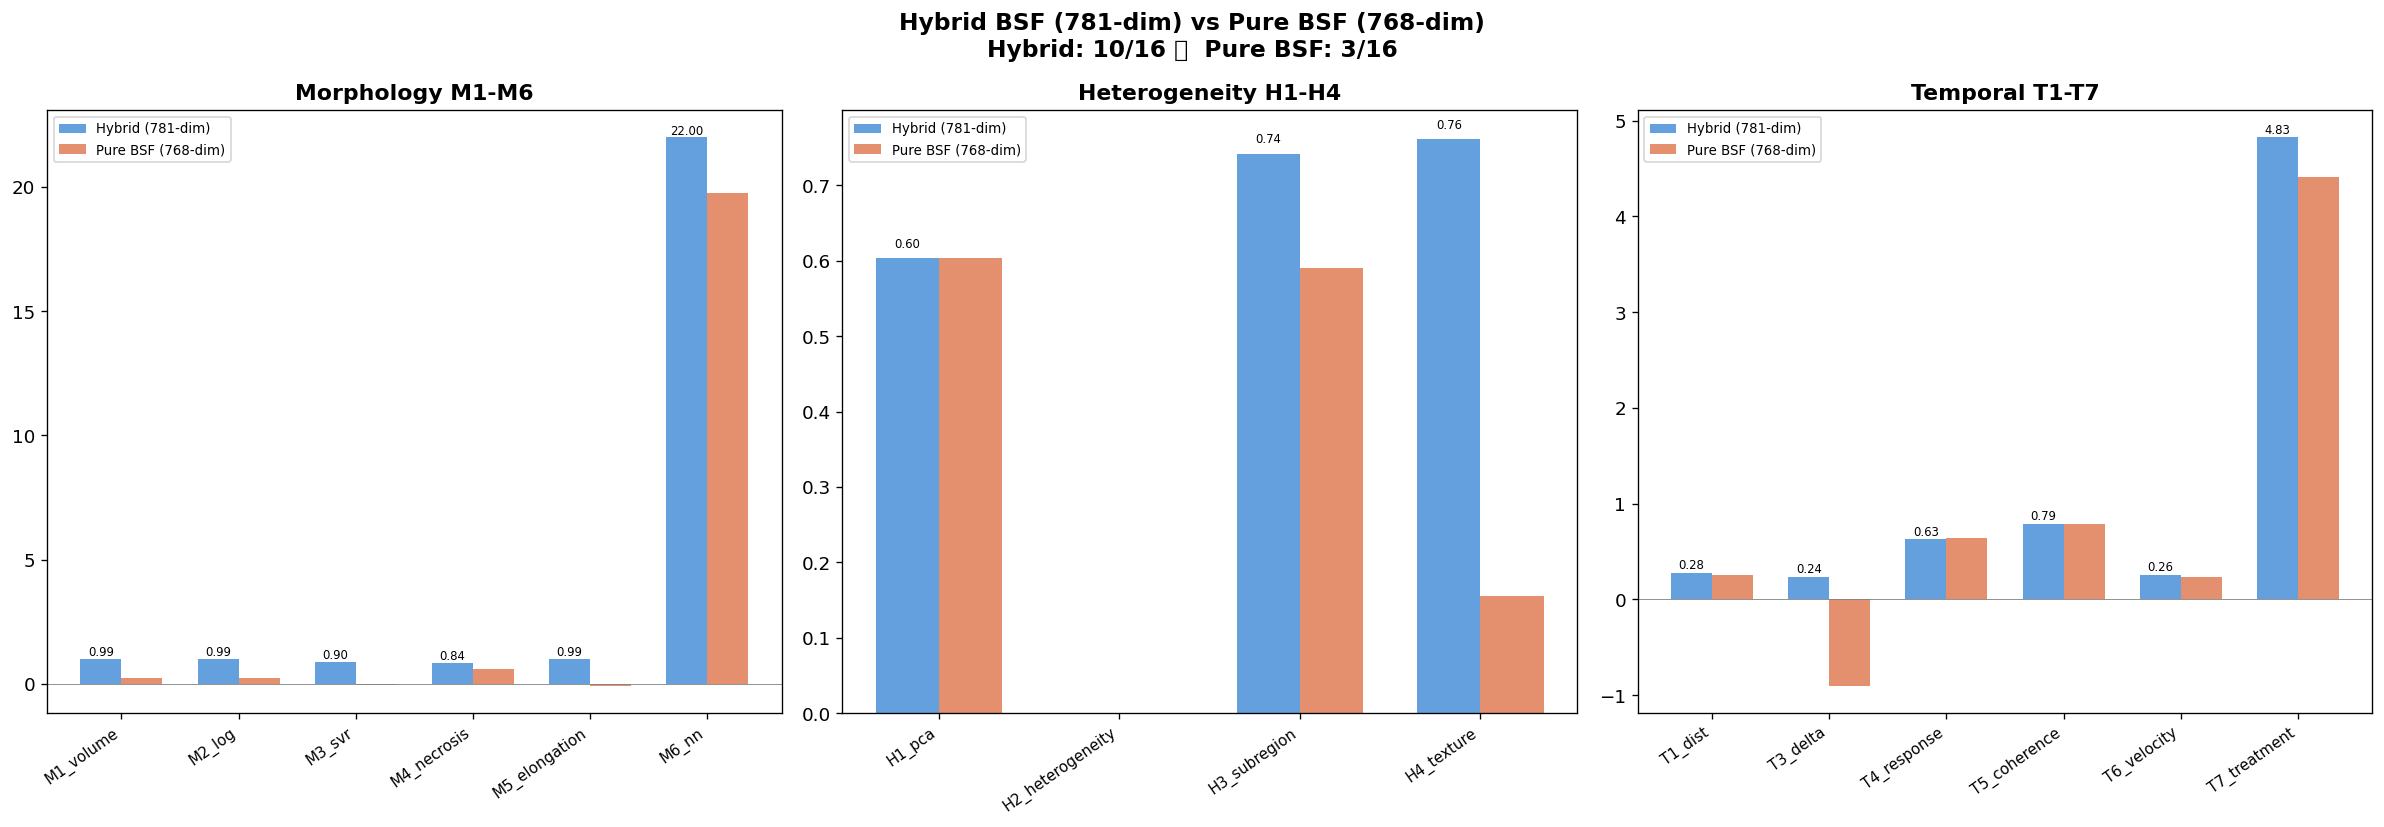


💾 Figure saved to: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a4b/hybrid_vs_pure_bsf.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

categories = [

    ('Morphology M1-M6', ['M1_volume_R2','M2_log_volume_R2','M3_svr_R2',

                           'M4_necrosis_F1','M5_elongation_R2','M6_nn_consistency_pct']),

    ('Heterogeneity H1-H4', ['H1_pca_residual_r','H2_heterogeneity_R2',

                              'H3_subregion_F1','H4_texture_bundle_R2']),

    ('Temporal T1-T7', ['T1_dist_vol_r','T3_delta_R2','T4_response_AUC',

                         'T5_coherence_cos','T6_velocity_r','T7_treatment_d']),

]

for ax, (title, keys) in zip(axes, categories):

    h_vals = [RESULTS_HYBRID.get(k, 0) for k in keys]

    p_vals = [RESULTS_PURE.get(k, 0)   for k in keys]

    short_keys = [k.split('_')[0]+'_'+k.split('_')[1] for k in keys]

    x = np.arange(len(keys))

    w = 0.35

    bars_h = ax.bar(x - w/2, h_vals, w, label='Hybrid (781-dim)', color='#4A90D9', alpha=0.85)

    bars_p = ax.bar(x + w/2, p_vals, w, label='Pure BSF (768-dim)', color='#E07B54', alpha=0.85)

    ax.set_xticks(x); ax.set_xticklabels(short_keys, rotation=35, ha='right', fontsize=9)

    ax.set_title(title, fontweight='bold'); ax.axhline(0, color='gray', lw=0.5)

    ax.legend(fontsize=8)

    for bar in bars_h:

        v = bar.get_height()

        if abs(v) > 0.01:

            ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle(f'Hybrid BSF (781-dim) vs Pure BSF (768-dim)\nHybrid: {h_pass}/16 ✅  Pure BSF: {p_pass}/16',

             fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig(FIG_DIR/'hybrid_vs_pure_bsf.png', dpi=150, bbox_inches='tight')

plt.show()

print(f"\n💾 Figure saved to: {FIG_DIR/'hybrid_vs_pure_bsf.png'}")

In [ ]:
import json as _json

out_results = {

    'hybrid_781dim': {k: float(v) for k, v in RESULTS_HYBRID.items() if not np.isnan(float(v))},

    'pure_bsf_768dim': {k: float(v) for k, v in RESULTS_PURE.items() if not np.isnan(float(v))},

    'scores': {'hybrid': h_pass, 'pure_bsf': p_pass, 'improvement': h_pass - p_pass},

    'shape_features': feat_names,

    'embedding_dim': {'pure_bsf': 768, 'shape_features': 13, 'hybrid': 781},

    'cv_strategy': 'KFold(n_splits=5, shuffle=True, random_state=42)',

    'probe': 'StandardScaler → PCA(30) → Ridge(alpha=1.0)',

}

results_path = PHASE3 / "outputs" / "phase3_a4b_hybrid_results.json"

results_path.parent.mkdir(parents=True, exist_ok=True)

with open(results_path, 'w') as f:

    _json.dump(out_results, f, indent=2)

print(f"💾 Results saved to: {results_path}")

print(f"\n{'='*50}")

print(f"  Final Score:")

print(f"  Pure BSF (768-dim): {p_pass}/16 tests passed")

print(f"  Hybrid   (781-dim): {h_pass}/16 tests passed")

print(f"  Improvement:       +{h_pass-p_pass} tests")

print(f"{'='*50}")

💾 Results saved to: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/phase3_a4b_hybrid_results.json

  Final Score:
  Pure BSF (768-dim): 3/16 tests passed
  Hybrid   (781-dim): 10/16 tests passed
  Improvement:       +7 tests
